# Walk-forward analysis — tech5 universe

This notebook is **self-contained**: it reads the committed CSV
`results/walk_forward_tech5.csv` and reproduces the figures embedded in
the project README, plus a few extra cells that are easier to explore
interactively than as static PNGs.

The CSV was produced by:

```bash
conda run -n rlportfolio python -m evaluation.walk_forward \
    --config configs/opt_c_tech5.yaml \
    --t-min-days 756 --stride-days 63 \
    --seeds 42 43 44 \
    --output results/walk_forward_tech5.csv

conda run -n rlportfolio python scripts/add_market_benchmark.py \
    results/walk_forward_tech5.csv \
    --ticker '^GSPC' --column-prefix sp500
```

You do **not** need finbase, stable-baselines3, or any market data
access to run this notebook — only `pandas`, `numpy`, and
`matplotlib`, all of which ship with `environment.yml`.


## 1. Load the CSV and inspect schema


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_rows', 20)

CSV = Path('../results/walk_forward_tech5.csv')
df = pd.read_csv(CSV)
df['test_start'] = pd.to_datetime(df['test_start'])
df['test_end'] = pd.to_datetime(df['test_end'])

# Drop failed runs from analysis (none in the committed CSV, but kept
# for safety on future re-runs).
if 'status' in df.columns:
    df = df[df['status'] == 'success'].copy()

print(f'rows                : {len(df):4d}')
print(f'unique folds        : {df["fold"].nunique():4d}')
print(f'unique seeds        : {df["seed"].nunique():4d}')
print(f'first test window   : {df["test_start"].min().date()}')
print(f'last test window    : {df["test_end"].max().date()}')
print()
df.head()

rows                :  219
unique folds        :   73
unique seeds        :    3
first test window   : 2008-01-04
last test window    : 2026-04-16



,fold,train_start,sel_start,test_start,test_end,seed,universe_mode,survivorship_bias,n_assets,tickers_hash,...,agent_vol,error_type,error_message,error_traceback,buy_and_hold_sharpe,buy_and_hold_return,equal_weight_sharpe,equal_weight_return,sp500_sharpe,sp500_return
0,0,2005-01-03,2007-07-06,2008-01-04,2008-04-04,42,static_current,known,5,4020ad4ff1ee,...,0.336893,NaN,NaN,NaN,-2.425252,-0.219240,-2.322885,-0.212809,-0.465398,-0.032326
1,0,2005-01-03,2007-07-06,2008-01-04,2008-04-04,43,static_current,known,5,4020ad4ff1ee,...,0.336525,NaN,NaN,NaN,-2.425252,-0.219240,-2.322885,-0.212809,-0.465398,-0.032326
2,0,2005-01-03,2007-07-06,2008-01-04,2008-04-04,44,static_current,known,5,4020ad4ff1ee,...,0.334493,NaN,NaN,NaN,-2.425252,-0.219240,-2.322885,-0.212809,-0.465398,-0.032326
3,1,2005-01-03,2007-10-04,2008-04-07,2008-07-03,42,static_current,known,5,4020ad4ff1ee,...,0.262755,NaN,NaN,NaN,-0.734882,-0.062062,-0.704243,-0.060652,-2.074689,-0.075164
4,1,2005-01-03,2007-10-04,2008-04-07,2008-07-03,43,static_current,known,5,4020ad4ff1ee,...,0.296446,NaN,NaN,NaN,-0.734882,-0.062062,-0.704243,-0.060652,-2.074689,-0.075164


## 2. Aggregate summary


In [2]:
BASELINES = ['buy_and_hold', 'equal_weight', 'sp500']

rows = []
for name, sharpe_col, ret_col in [
    ('PPO agent', 'agent_sharpe', 'agent_return'),
    *[(b, f'{b}_sharpe', f'{b}_return') for b in BASELINES],
]:
    sh = df[sharpe_col].replace([np.inf, -np.inf], np.nan).dropna()
    rt = df[ret_col].replace([np.inf, -np.inf], np.nan).dropna()
    if name == 'PPO agent':
        hit = ''
    else:
        comp = df[['agent_sharpe', sharpe_col]].replace([np.inf, -np.inf], np.nan).dropna()
        hit = f'{(comp.agent_sharpe > comp[sharpe_col]).mean():.0%}' if len(comp) else 'n/a'
    rows.append({
        'strategy': name,
        'mean_sharpe': sh.mean(),
        'median_sharpe': sh.median(),
        'sharpe_std': sh.std(),
        'mean_return': rt.mean(),
        'hit_rate_vs_agent': hit,
    })

summary = pd.DataFrame(rows)
summary

,strategy,mean_sharpe,median_sharpe,sharpe_std,mean_return,hit_rate_vs_agent
0,PPO agent,1.273232,1.359773,1.963414,0.050870,
1,buy_and_hold,1.343674,1.508977,1.976032,0.063230,40%
2,equal_weight,1.345781,1.346125,1.968802,0.062729,40%
3,sp500,1.038715,1.185468,1.787808,0.023188,54%


On the tech5 universe, with these features and this training budget,
the agent's **mean Sharpe trails the in-universe baselines by ~0.07**
and beats them in only 40 % of (fold, seed) runs. The agent edges the
S&P 500 — but so do the in-universe baselines by an even larger
margin, so the apparent edge over the broad market is **universe
selection, not the RL policy**.


## 3. Cumulative return over the full walk-forward path


Each fold reports a per-quarter total return. Stitching them
end-to-end gives a continuous "what would $1 have grown to under this
protocol" curve. Note this is *not* an actual tradable equity curve
because each fold's agent is a fresh model trained on the prior
history — but it is the right comparison for the protocol because
every strategy gets the same treatment.


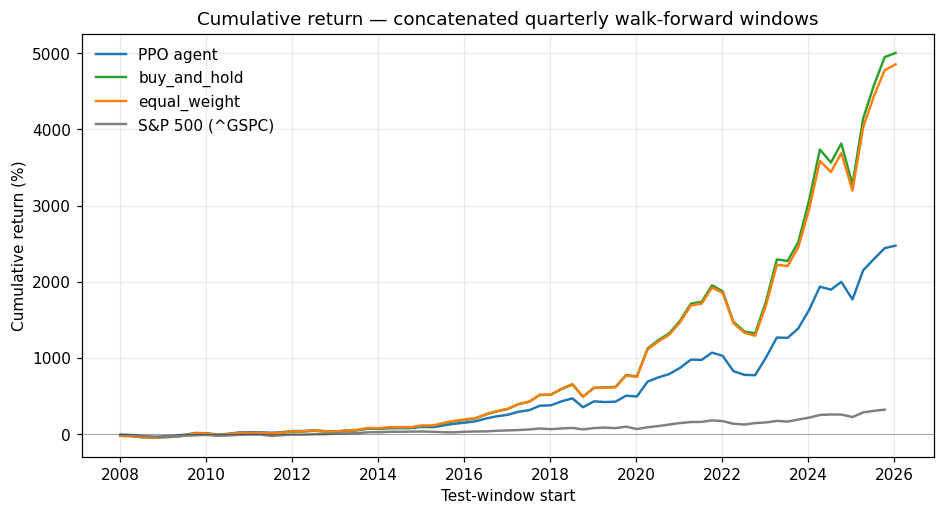

In [3]:
def per_fold_mean(col: str) -> pd.Series:
    return (df[['fold', col]]
            .replace([np.inf, -np.inf], np.nan)
            .groupby('fold')[col].mean())

dates = (df[['fold', 'test_start']]
         .drop_duplicates('fold')
         .set_index('fold')['test_start'])

fig, ax = plt.subplots(figsize=(10, 5))
for col, label, colour in [
    ('agent_return',         'PPO agent',       '#1f77b4'),
    ('buy_and_hold_return',  'buy_and_hold',    '#2ca02c'),
    ('equal_weight_return',  'equal_weight',    '#ff7f0e'),
    ('sp500_return',         'S&P 500 (^GSPC)', '#7f7f7f'),
]:
    cum = np.cumprod(1.0 + per_fold_mean(col).values) - 1.0
    ax.plot(dates.values, cum * 100, label=label, color=colour, lw=1.6)
ax.axhline(0, color='black', lw=0.5, alpha=0.4)
ax.set_title('Cumulative return — concatenated quarterly walk-forward windows')
ax.set_ylabel('Cumulative return (%)')
ax.set_xlabel('Test-window start')
ax.legend(loc='upper left', frameon=False)
ax.grid(alpha=0.25)
plt.show()

## 4. Per-window Sharpe distribution


Boxplots collapse the 219 per-(fold, seed) Sharpe values per strategy.
Heavy overlap is the headline: at the resolution of a single quarterly
window, the four distributions are nearly indistinguishable.


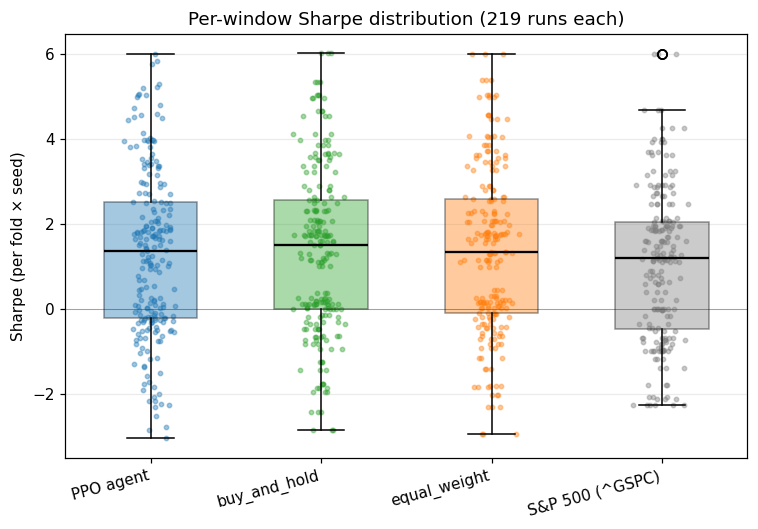

In [4]:
cols = ['agent_sharpe'] + [f'{b}_sharpe' for b in BASELINES]
labels = ['PPO agent', 'buy_and_hold', 'equal_weight', 'S&P 500 (^GSPC)']
colours = ['#1f77b4', '#2ca02c', '#ff7f0e', '#7f7f7f']
data = [df[c].replace([np.inf, -np.inf], np.nan).dropna().values for c in cols]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data, vert=True, widths=0.55, patch_artist=True,
                medianprops={'color': 'black', 'lw': 1.5},
                boxprops={'alpha': 0.4})
for patch, c in zip(bp['boxes'], colours):
    patch.set_facecolor(c)
rng = np.random.RandomState(0)
for i, (vals, c) in enumerate(zip(data, colours), start=1):
    ax.scatter(rng.normal(i, 0.06, size=len(vals)), vals, s=8, alpha=0.4, color=c)
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.axhline(0, color='black', lw=0.5, alpha=0.4)
ax.set_ylabel('Sharpe (per fold × seed)')
ax.set_title(f'Per-window Sharpe distribution ({len(data[0])} runs each)')
ax.grid(alpha=0.25, axis='y')
plt.show()

## 5. Rolling 4-fold mean Sharpe


Smoothed view over time. The agent and in-universe baselines move
almost identically through every regime — consistent with the agent
learning a near-equal-weight policy.


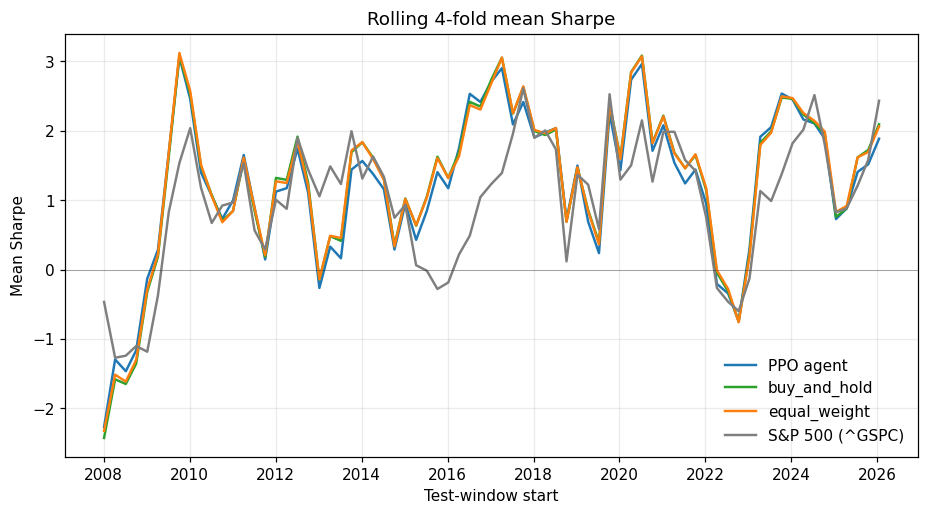

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for col, label, colour in [
    ('agent_sharpe',         'PPO agent',       '#1f77b4'),
    ('buy_and_hold_sharpe',  'buy_and_hold',    '#2ca02c'),
    ('equal_weight_sharpe',  'equal_weight',    '#ff7f0e'),
    ('sp500_sharpe',         'S&P 500 (^GSPC)', '#7f7f7f'),
]:
    s = (per_fold_mean(col)
         .replace([np.inf, -np.inf], np.nan)
         .rolling(4, min_periods=1).mean())
    ax.plot(dates.values, s.values, label=label, color=colour, lw=1.6)
ax.axhline(0, color='black', lw=0.5, alpha=0.4)
ax.set_title('Rolling 4-fold mean Sharpe')
ax.set_ylabel('Mean Sharpe')
ax.set_xlabel('Test-window start')
ax.legend(loc='lower right', frameon=False)
ax.grid(alpha=0.25)
plt.show()

## 6. Rolling hit rate vs each baseline


The most diagnostic plot. The 50% line is parity. Persistent
deviations either way are interesting; the 2014-2022 stretch where
the agent loses to in-universe baselines >60% of the time is the
clearest signal in this CSV.


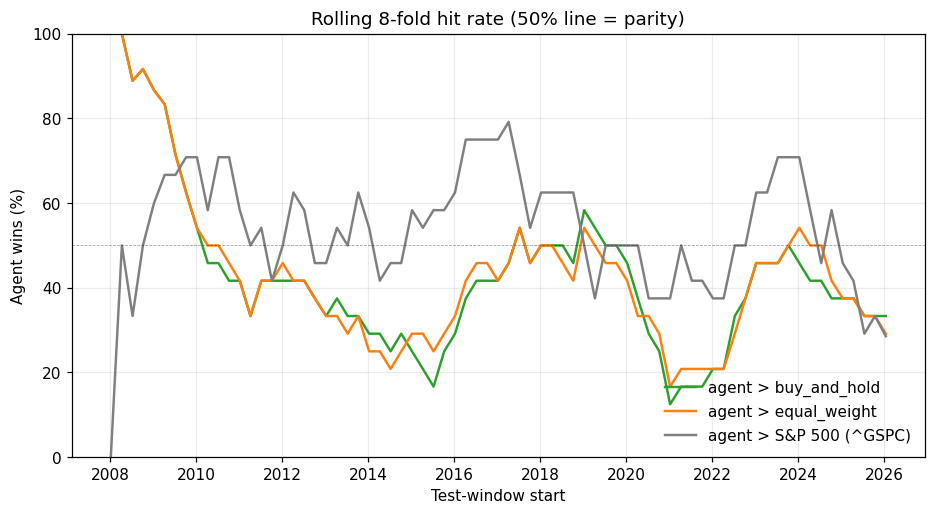

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
fold_idx = sorted(df['fold'].unique())
for col, label, colour in [
    ('buy_and_hold_sharpe',  'agent > buy_and_hold',    '#2ca02c'),
    ('equal_weight_sharpe',  'agent > equal_weight',    '#ff7f0e'),
    ('sp500_sharpe',         'agent > S&P 500 (^GSPC)', '#7f7f7f'),
]:
    comp = df[['fold', 'agent_sharpe', col]].replace([np.inf, -np.inf], np.nan).dropna()
    wins = ((comp['agent_sharpe'] > comp[col])
            .groupby(comp['fold']).mean()
            .reindex(fold_idx))
    rolled = wins.rolling(8, min_periods=1).mean() * 100
    ax.plot(dates.values, rolled.values, label=label, color=colour, lw=1.6)
ax.axhline(50, color='black', lw=0.5, alpha=0.4, linestyle='--')
ax.set_title('Rolling 8-fold hit rate (50% line = parity)')
ax.set_ylabel('Agent wins (%)')
ax.set_xlabel('Test-window start')
ax.set_ylim(0, 100)
ax.legend(loc='lower right', frameon=False)
ax.grid(alpha=0.25)
plt.show()

## 7. Seed dispersion — how stable is the agent?


For each fold, what is the spread between the best and worst seed?
Tight spread = stable training; wide spread = run-to-run lottery.


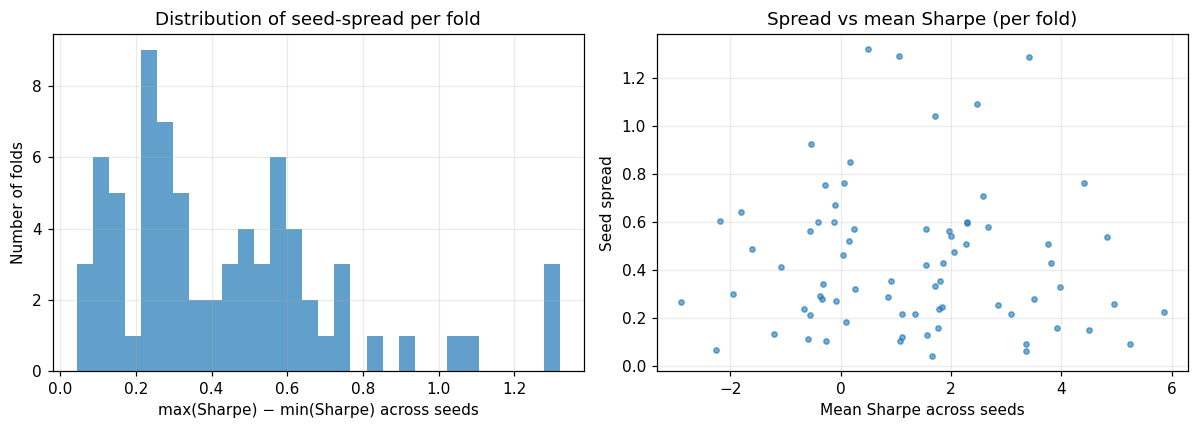

median seed-spread: 0.355
mean   seed-spread: 0.436
>1.0 spread folds : 5 / 73


In [7]:
per_fold = (df.groupby('fold')['agent_sharpe']
              .agg(['min', 'mean', 'max', 'std']))
per_fold['spread'] = per_fold['max'] - per_fold['min']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(per_fold['spread'].dropna(), bins=30, color='#1f77b4', alpha=0.7)
axes[0].set_title('Distribution of seed-spread per fold')
axes[0].set_xlabel('max(Sharpe) − min(Sharpe) across seeds')
axes[0].set_ylabel('Number of folds')
axes[0].grid(alpha=0.25)

axes[1].scatter(per_fold['mean'], per_fold['spread'], s=12, alpha=0.6, color='#1f77b4')
axes[1].set_title('Spread vs mean Sharpe (per fold)')
axes[1].set_xlabel('Mean Sharpe across seeds')
axes[1].set_ylabel('Seed spread')
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f'median seed-spread: {per_fold.spread.median():.3f}')
print(f'mean   seed-spread: {per_fold.spread.mean():.3f}')
print(f'>1.0 spread folds : {(per_fold.spread > 1.0).sum()} / {len(per_fold)}')

## 8. Per-fold detail (sortable)


Each row is one fold's mean across seeds. Sort by `agent_minus_eq` to
find the folds where the agent most beat / lost to the equal-weight
baseline.


In [8]:
per_fold_full = (df.groupby('fold')
                   .agg(test_start=('test_start', 'first'),
                        test_end=('test_end', 'first'),
                        agent_sharpe=('agent_sharpe', 'mean'),
                        bh_sharpe=('buy_and_hold_sharpe', 'mean'),
                        eq_sharpe=('equal_weight_sharpe', 'mean'),
                        sp500_sharpe=('sp500_sharpe', 'mean'),
                        agent_return=('agent_return', 'mean'))
                   .round(3))
per_fold_full['agent_minus_eq'] = (
    per_fold_full['agent_sharpe'] - per_fold_full['eq_sharpe']
).round(3)
per_fold_full.sort_values('agent_minus_eq', ascending=False).head(10)

/var/folders/qd/kdd665cj5_9g6vf6zqc12dfm0000gn/T/ipykernel_72553/2163802885.py:9: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(3))


,test_start,test_end,agent_sharpe,bh_sharpe,eq_sharpe,sp500_sharpe,agent_return,agent_minus_eq
fold,,,,,,,,
33,2016-04-08,2016-07-07,1.790,1.509,1.285,0.628,0.075,0.505
1,2008-04-07,2008-07-03,-0.321,-0.735,-0.704,-2.075,-0.029,0.383
12,2011-01-04,2011-04-04,0.501,0.087,0.201,1.392,0.029,0.300
41,2018-04-10,2018-07-09,2.860,2.560,2.589,1.689,0.111,0.271
27,2014-10-07,2015-01-06,0.035,-0.203,-0.202,0.887,0.003,0.237
66,2024-07-15,2024-10-10,-0.337,-0.649,-0.562,0.587,-0.019,0.225
10,2010-07-07,2010-10-04,2.472,2.292,2.264,1.594,0.119,0.208
60,2023-01-10,2023-04-11,3.750,3.581,3.555,1.143,0.266,0.195
31,2015-10-07,2016-01-06,2.266,2.095,2.072,-0.166,0.107,0.194


In [9]:
per_fold_full.sort_values('agent_minus_eq').head(10)

,test_start,test_end,agent_sharpe,bh_sharpe,eq_sharpe,sp500_sharpe,agent_return,agent_minus_eq
fold,,,,,,,,
22,2013-07-09,2013-10-04,1.049,1.564,1.635,0.800,0.035,-0.586
29,2015-04-09,2015-07-08,-0.536,0.026,0.024,-0.997,-0.016,-0.560
70,2025-07-17,2025-10-14,1.762,2.300,2.241,1.897,0.067,-0.479
45,2019-04-10,2019-07-10,-0.378,0.108,0.054,1.116,-0.017,-0.432
13,2011-04-05,2011-07-05,-0.281,0.100,0.125,0.001,-0.010,-0.406
54,2021-07-12,2021-10-07,-0.113,0.255,0.257,-0.029,-0.003,-0.370
36,2017-01-06,2017-04-06,2.283,2.639,2.640,1.850,0.059,-0.357
65,2024-04-12,2024-07-12,3.352,3.639,3.708,3.692,0.178,-0.356
39,2017-10-06,2018-01-05,3.092,3.349,3.371,4.668,0.137,-0.279


## 9. What this notebook does NOT do


- **No statistical test** of whether the per-fold Sharpe deltas are
  distinguishable from zero. With 73 folds × 3 seeds, a paired
  bootstrap would be the natural next step. Not implemented here.
- **No ablations** — same features, same reward, same architecture
  throughout. The result is a property of *one* config, not RL on
  this universe in general.
- **No inspection of the learned policy.** The agent's per-step
  weights are not in this CSV. To peek at allocations, run the
  backtest interactively against `PortfolioEnv` and inspect
  `env.get_portfolio_history()`.

See `README.md` → "Limitations & Honest Caveats" for the full list.
